# German electricity load — exploratory analysis

Hourly grid load (Netzlast) for Germany from [SMARD](https://www.smard.de), alongside
temperature (Open-Meteo), day-ahead price and generation mix (Energy-Charts). The goal
of this notebook is to understand the structure a forecaster has to exploit: the daily,
weekly and yearly seasonality, the holiday effect, data quality, and how load relates to
temperature and price.

In [1]:
import sys; sys.path.insert(0, "..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from src import config

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (11, 4)

df = pd.read_parquet(config.DATASET_PARQUET)
load = df[config.TARGET]
print(df.shape, "|", df.index.min(), "->", df.index.max())
df.head()

(48287, 7) | 2021-01-01 00:00:00+01:00 -> 2026-07-05 23:00:00+02:00


,load_MW,load_imputed,temp_DE,price_EUR_MWh,solar_MW,wind_MW,renewable_share
timestamp,,,,,,,
2021-01-01 00:00:00+01:00,44569.25,False,NaN,50.87,0.0,4342.175,0.25300
2021-01-01 01:00:00+01:00,42806.00,False,0.748750,48.19,0.0,3950.200,0.25325
2021-01-01 02:00:00+01:00,41049.75,False,0.694688,44.68,0.0,3528.500,0.25275
2021-01-01 03:00:00+01:00,40233.75,False,0.591563,42.92,0.0,3110.100,0.24700
2021-01-01 04:00:00+01:00,40210.50,False,0.749688,40.39,0.7,2778.300,0.23800


## The load series
Grid load in MW over the full sample. Note the strong yearly cycle (winter peaks) and the weekly texture.

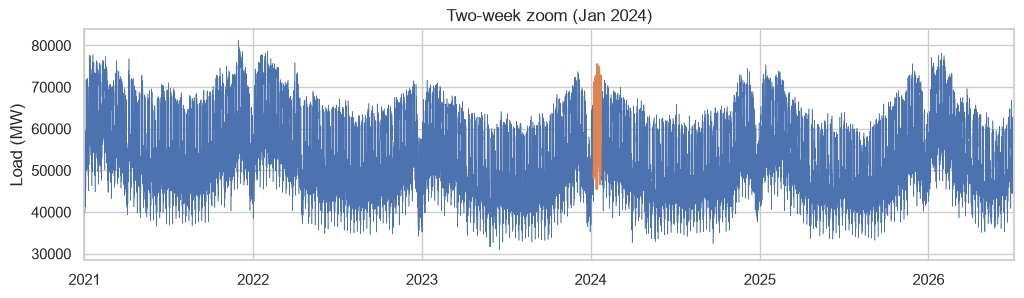

In [2]:
fig, ax = plt.subplots(figsize=(12, 4))
load.plot(ax=ax, lw=0.4)
ax.set(ylabel="Load (MW)", xlabel="", title="German grid load, hourly")
# a two-week zoom to reveal the daily/weekly shape
ax2 = load.loc["2024-01-08":"2024-01-22"].plot(figsize=(12, 3), title="Two-week zoom (Jan 2024)")
ax2.set(ylabel="Load (MW)", xlabel="")
plt.show()

## Seasonality: daily, weekly, yearly
Average load by hour-of-day, day-of-week and month — the three cycles a model must capture.

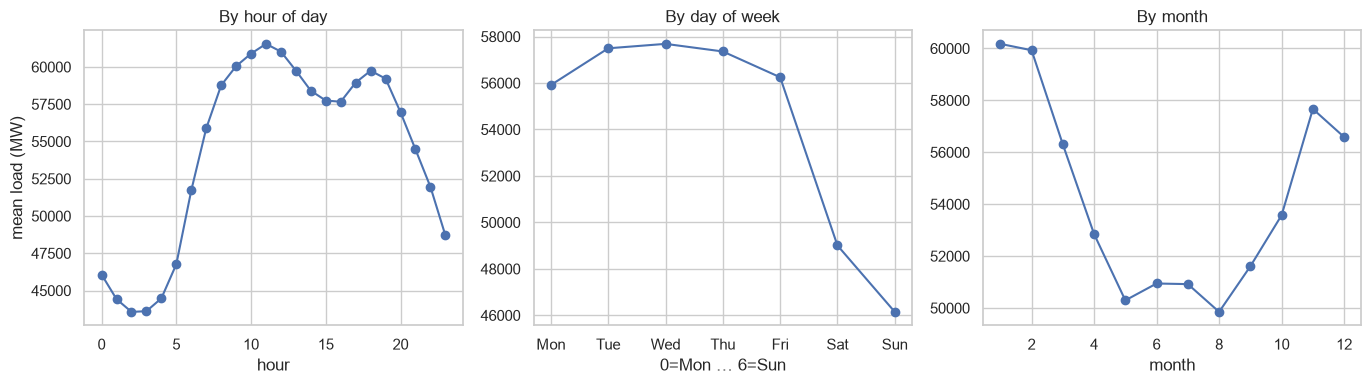

In [3]:
by_hour = load.groupby(load.index.hour).mean()
by_dow = load.groupby(load.index.dayofweek).mean()
by_month = load.groupby(load.index.month).mean()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
by_hour.plot(ax=axes[0], marker="o"); axes[0].set(title="By hour of day", xlabel="hour", ylabel="mean load (MW)")
by_dow.plot(ax=axes[1], marker="o"); axes[1].set(title="By day of week", xlabel="0=Mon … 6=Sun")
axes[1].set_xticks(range(7)); axes[1].set_xticklabels(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"])
by_month.plot(ax=axes[2], marker="o"); axes[2].set(title="By month", xlabel="month")
plt.tight_layout(); plt.show()

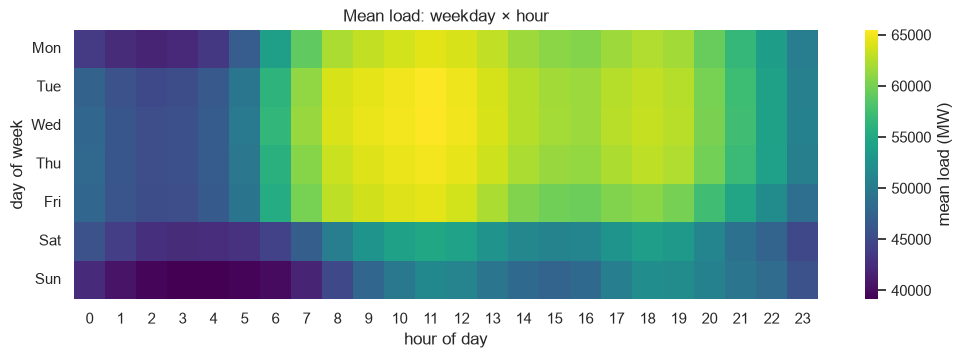

In [4]:
# Hour-by-weekday heatmap: weekday commuting peaks vs. flat weekends
pivot = load.groupby([load.index.dayofweek, load.index.hour]).mean().unstack()
fig, ax = plt.subplots(figsize=(12, 3.5))
sns.heatmap(pivot, cmap="viridis", ax=ax, cbar_kws={"label": "mean load (MW)"})
ax.set(xlabel="hour of day", ylabel="day of week", title="Mean load: weekday × hour")
ax.set_yticklabels(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"], rotation=0)
plt.show()

## Holiday effect
German public holidays behave like Sundays regardless of weekday — a feature the model gets explicitly.

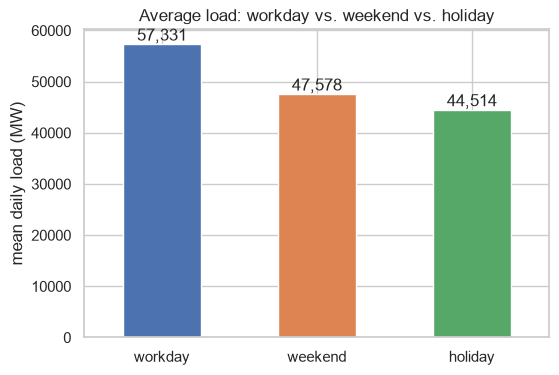

In [5]:
import holidays
de = holidays.Germany()
is_hol = pd.Series([d.date() in de for d in load.index], index=load.index)
daily = load.resample("D").mean()
daily_hol = pd.Series([d.date() in de for d in daily.index], index=daily.index)
comp = pd.DataFrame({
    "workday": daily[(daily.index.dayofweek < 5) & (~daily_hol)],
    "weekend": daily[daily.index.dayofweek >= 5],
    "holiday": daily[daily_hol],
})
ax = comp.mean().plot.bar(color=["#4c72b0","#dd8452","#55a868"], figsize=(6,4), rot=0)
ax.set(ylabel="mean daily load (MW)", title="Average load: workday vs. weekend vs. holiday")
for i, v in enumerate(comp.mean()):
    ax.text(i, v, f"{v:,.0f}", ha="center", va="bottom")
plt.show()

## Data quality: gaps and imputation
Hours flagged during ingestion (`load_imputed`) and any remaining missing values. Short gaps (≤3h) were interpolated and flagged; longer holes are left as NaN.

rows: 48,287
imputed (short gaps): 77
still missing load:   77

missing % by column:
 load_MW            0.159
solar_MW           0.159
renewable_share    0.159
wind_MW            0.157
price_EUR_MWh      0.149
temp_DE            0.147


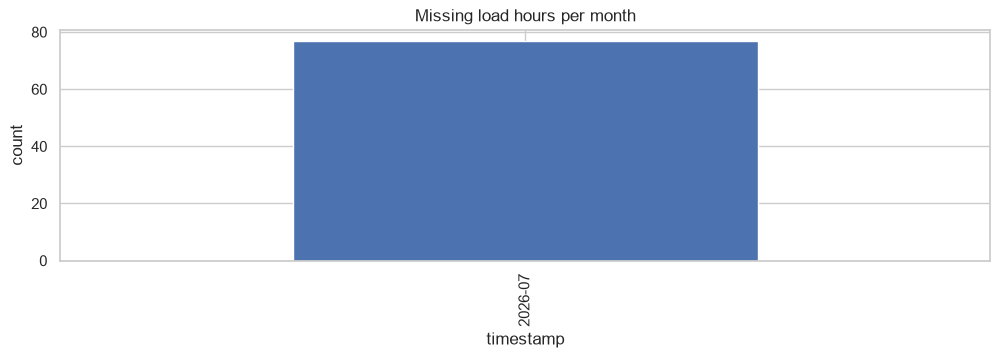

In [6]:
n = len(df)
print(f"rows: {n:,}")
print(f"imputed (short gaps): {int(df['load_imputed'].sum())}")
print(f"still missing load:   {int(load.isna().sum())}")
miss = df.drop(columns='load_imputed').isna().mean().sort_values(ascending=False) * 100
print("\nmissing % by column:\n", miss.round(3).to_string())
# where are the gaps?
gaps = load[load.isna()]
if len(gaps):
    g = gaps.resample("MS").size()
    g = g[g > 0]
    g.index = g.index.strftime("%Y-%m")
    ax = g.plot(kind="bar", figsize=(12,3))
    ax.set(title="Missing load hours per month", ylabel="count"); plt.show()
else:
    print("\nno remaining missing load hours")

## Distribution and autocorrelation
The load distribution and its autocorrelation — the 24h and 168h spikes justify the lag features.

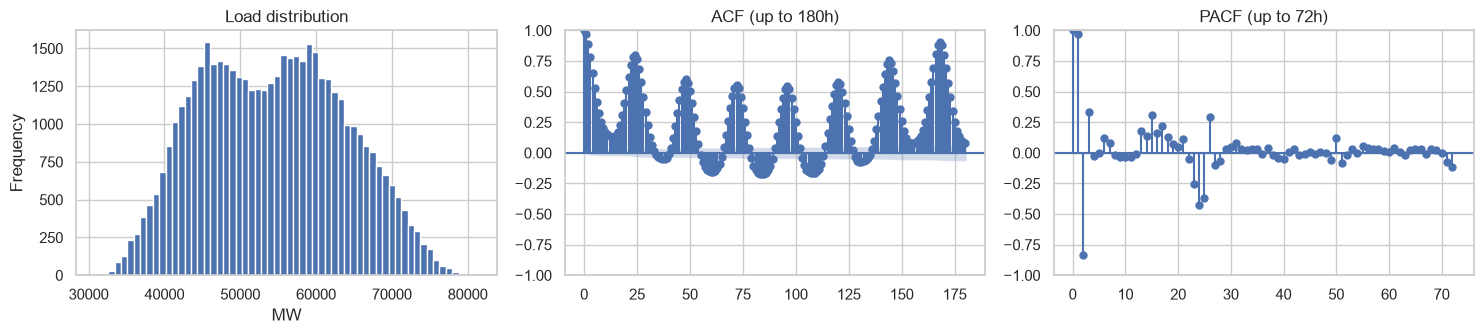

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
load.plot.hist(bins=60, ax=axes[0]); axes[0].set(title="Load distribution", xlabel="MW")
s = load.dropna()
plot_acf(s, lags=180, ax=axes[1]); axes[1].set(title="ACF (up to 180h)")
plot_pacf(s, lags=72, ax=axes[2], method="ywm"); axes[2].set(title="PACF (up to 72h)")
plt.tight_layout(); plt.show()

## Load vs. weather and price
Temperature drives demand (heating below ~15 °C, some cooling in summer → a U-shape). Price and load are positively related but noisy.

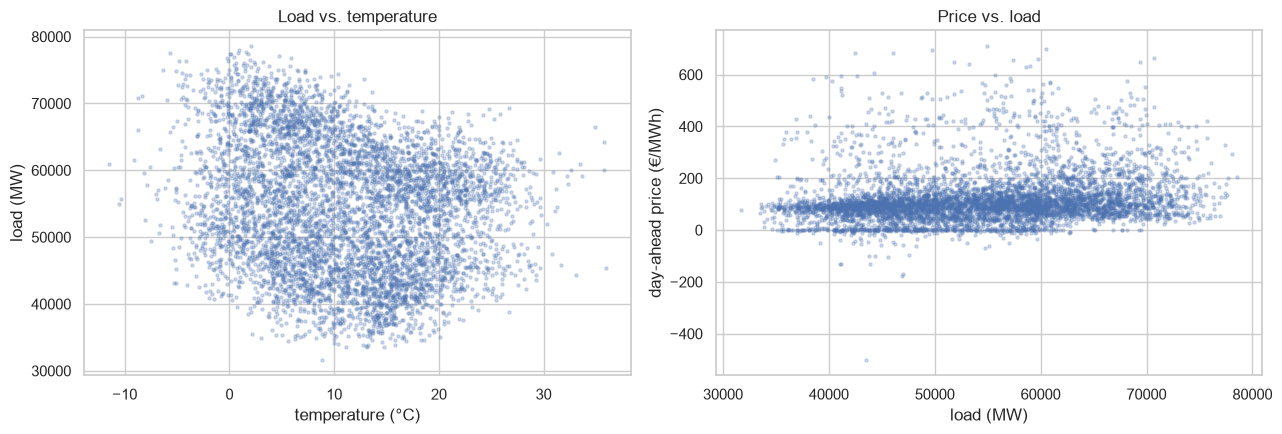

In [8]:
sample = df.dropna(subset=[config.TARGET, "temp_DE", "price_EUR_MWh"]).sample(
    min(6000, len(df)), random_state=config.SEED)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].scatter(sample["temp_DE"], sample[config.TARGET], s=5, alpha=0.25)
axes[0].set(xlabel="temperature (°C)", ylabel="load (MW)", title="Load vs. temperature")
axes[1].scatter(sample[config.TARGET], sample["price_EUR_MWh"], s=5, alpha=0.25)
axes[1].set(xlabel="load (MW)", ylabel="day-ahead price (€/MWh)", title="Price vs. load")
plt.tight_layout(); plt.show()

## Takeaways for modelling

- **Three seasonalities** (hour, weekday, month) plus a clear **holiday effect** → calendar features.
- Strong **24h and 168h autocorrelation** → lagged-load features are the backbone.
- **Temperature** has a U-shaped relationship with load → a useful exogenous driver.
- Data quality is good; only a handful of short gaps needed interpolation.

Next: baselines (naive / seasonal-naive) and a rolling-origin backtest — see `src/evaluate.py`.